## Demo for modelling single-channel PSF from bead data

#### Setup environment

In [1]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf
#main_data_dir = io.param.load('datapath.yaml').main_data_dir
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{psftype}}$:  `'voxel', 'zernike'`  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_user')
```

In [43]:
L = psflearninglib()
L.param = io.param.combine('config_base',psftype='insitu',channeltype='2ch',sysfile='smart_tirf')


#### Edit user defined parameters

In [44]:
L.param.datapath = r'C:\Users\Sheng\Documents\MATLAB\bead100nm_smart/'
L.param.keyword = '100nmbeads-0.5exp-noFocusLock-8000Frames--2025-07-23_18-57-18' # keyword for your data file
L.param.savename = L.param.datapath+'python/result_2ch/' + L.param.keyword
L.param.subfolder = '' # keyword for subfolder name if each data file is saved in a individual folder, set to '' if no subfolder
L.param.gain = 0.24
L.param.ccd_offset = 100
L.param.ref_channel = 0 # choose the brighter channel as the reference channel, 0 or 1
L.param.batch_size = 500 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.varname = 'Main/data'
L.param.option.insitu.stage_pos = 0.6 
L.param.option.model.n_max = 6
L.param.option.insitu.z_range = 1.0
L.param.option.insitu.repeat=2
L.param.insitu.frame_range = [0,2000]
L.param.option.model.const_pupilmag = True
L.param.option.insitu.var_stagepos = False
L.param.plotall = True

#### Start learning

In [45]:
images = L.load_data()

C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\100nmbeads-0.5exp-noFocusLock-8000Frames--2025-07-23_18-57-18.h5
(2, 2000, 420, 256)


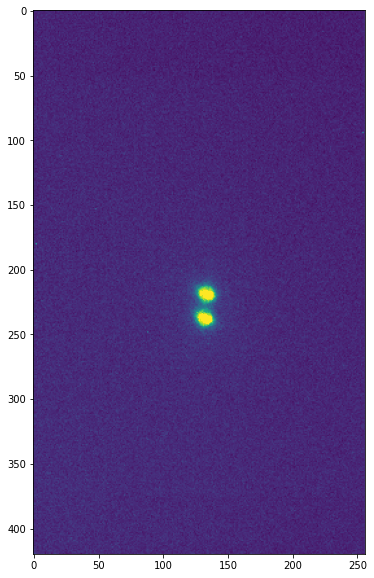

In [46]:
plt.figure(figsize=(10, 10))
plt.imshow(images[1][-1],clim=(0, np.quantile(images,0.999)))

Image size: (256, 256)


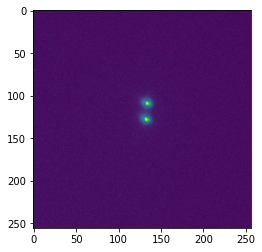

In [47]:
imsz = 256
startx = 0
starty = 110
plt.imshow(images[1][-1][starty:starty+imsz,startx:startx+imsz])
print('Image size:', images[0][0][starty:starty+imsz,startx:startx+imsz].shape)

In [48]:
images = images[:,:,starty:starty+imsz,startx:startx+imsz]

rois shape channel 0: (1180, 17, 17)
rois shape channel 1: (1184, 17, 17)


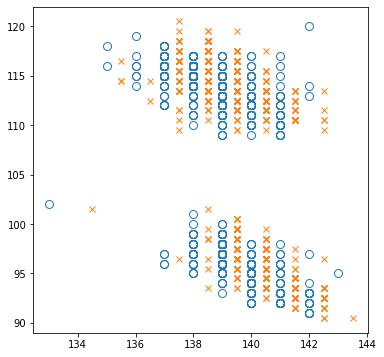

rois shape channel 0: (822, 17, 17)
rois shape channel 1: (822, 17, 17)


In [51]:
L.getpsfclass()
L.param.roi.roi_size = [17,17]
L.param.roi.peak_height = 0.6
dataobj = L.prep_data(images)

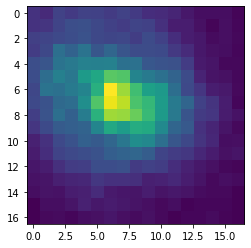

In [52]:
plt.imshow(dataobj.channels[1].rois[-1])

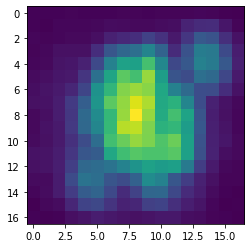

In [53]:
plt.imshow(np.max(dataobj.channels[1].rois, axis=0))

4/6: calculating spline coefficients: 1/1 [00:00s]  2.09it/s total time: 0.48s
5/6: localization: 2/2 [00:00s] 18.94it/s total time: 0.58s
3/6: learning: 57/100 [00:05s]  9.68it/s, current loss: 1.02490, total time: 5.89s
4/6: calculating spline coefficients: 1/1 [00:00s]  1.94it/s total time: 6.40s
5/6: localization: 2/2 [00:00s] 11.60it/s total time: 6.57s
3/6: learning: 54/100 [00:05s] 10.02it/s, current loss: 1.34619, total time: 11.27s
4/6: calculating spline coefficients: 2/2 [00:00s]  2.03it/s total time: 0.98s
5/6: localization: 2/2 [00:00s]  3.19it/s total time: 1.60s
3/6: learning: 76/250 [00:16s]  4.68it/s, current loss: 7.62595, total time: 27.51s  


outlier percentage: 0.24137931034482762
rois shape channel 0: (66, 17, 17)
rois shape channel 1: (66, 17, 17)


3/6: learning: 53/250 [00:11s]  4.61it/s, current loss: 15.10118, total time: 39.01s 
4/6: calculating spline coefficients: 2/2 [00:00s]  2.10it/s total time: 0.95s
5/6: localization: 2/2 [00:00s]  2.44it/s total time: 1.76s
6/6: saving results: [00:01s] total time: 2.93s


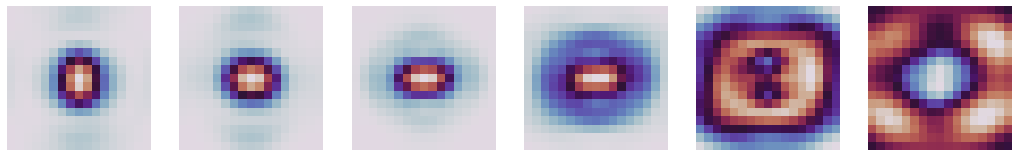

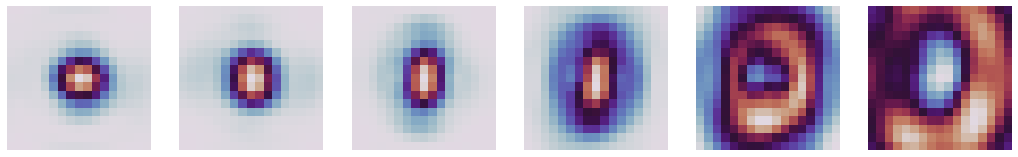

4/6: calculating spline coefficients: 1/1 [00:00s]  2.04it/s total time: 0.49s
5/6: localization: 2/2 [00:00s] 12.46it/s total time: 0.65s
3/6: learning: 53/100 [00:10s]  5.04it/s, current loss: 1.48562, total time: 10.52s
4/6: calculating spline coefficients: 1/1 [00:00s]  1.91it/s total time: 11.03s
5/6: localization: 2/2 [00:00s]  9.66it/s total time: 11.24s
3/6: learning: 52/100 [00:10s]  5.08it/s, current loss: 1.27223, total time: 20.74s
4/6: calculating spline coefficients: 2/2 [00:00s]  2.08it/s total time: 0.95s
5/6: localization: 2/2 [00:00s]  2.41it/s total time: 1.78s
3/6: learning: 211/250 [00:46s]  4.52it/s, current loss: 1.95861, total time: 67.37s


outlier percentage: 0.2583333333333333
rois shape channel 0: (267, 17, 17)
rois shape channel 1: (267, 17, 17)


3/6: learning: 59/250 [00:13s]  4.45it/s, current loss: 4.09794, total time: 80.62s 
4/6: calculating spline coefficients: 2/2 [00:01s]  1.97it/s total time: 1.01s
5/6: localization: 2/2 [00:00s]  3.42it/s total time: 1.59s
6/6: saving results: [00:01s] total time: 2.81s


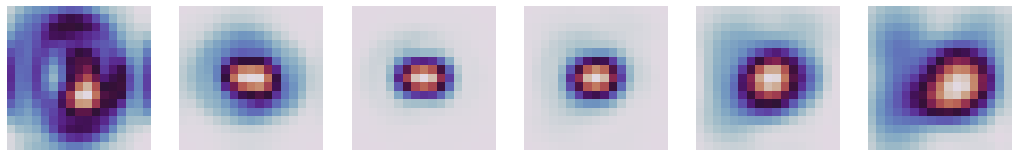

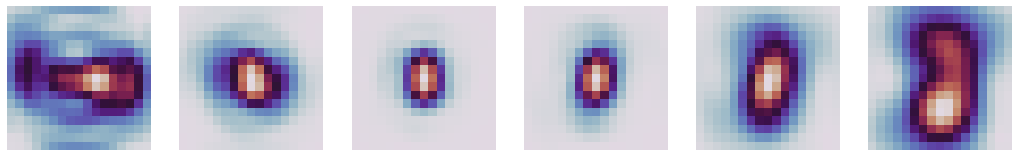

In [63]:
resfile = L.iterlearn_psf(dataobj,time=0)

#### Show results

In [64]:
f,p = io.h5.load(resfile) # load result file

channel 0


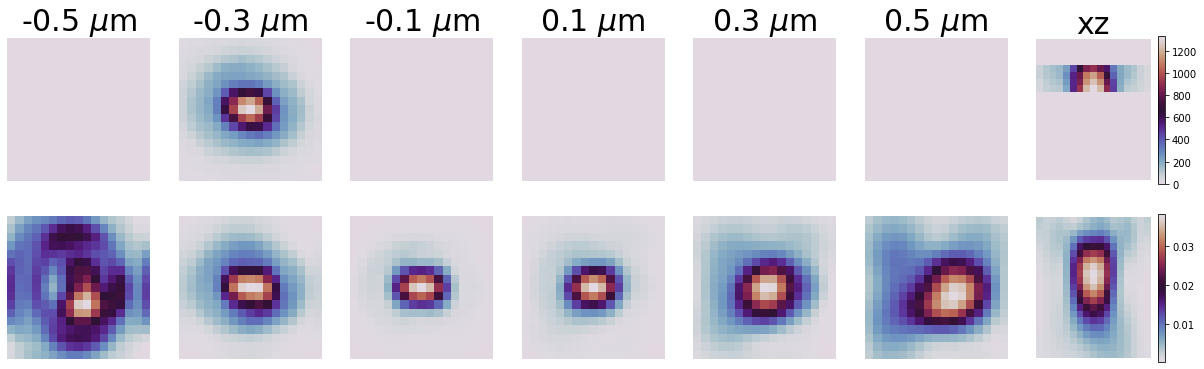

channel 1


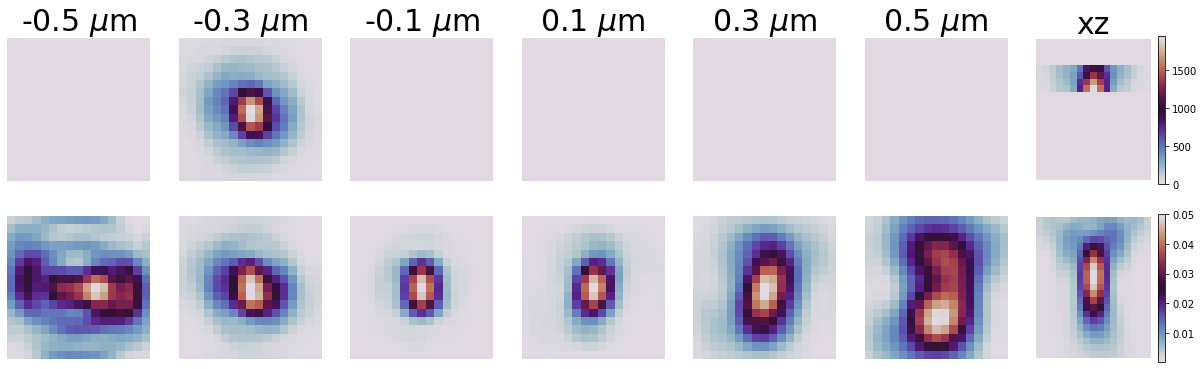

In [65]:
showpsfvsdata_insitu(f,p)

In [66]:
f.res.channel0.stagepos

array([0.6], dtype=float32)

In [67]:
[f.res.channel0.sigma,f.res.channel1.sigma]

[array([0.8026, 0.6987], dtype=float32),
 array([0.6742, 0.6898], dtype=float32)]

#### Optional plots

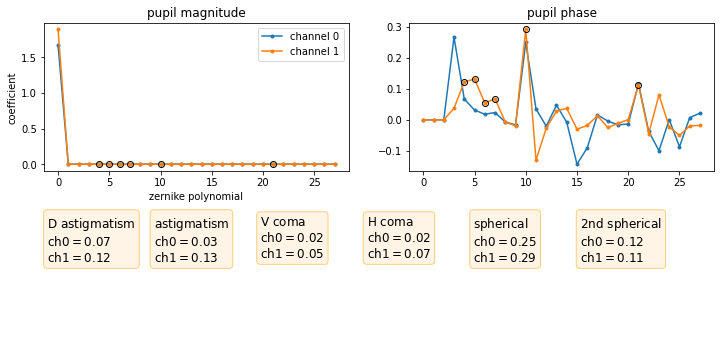

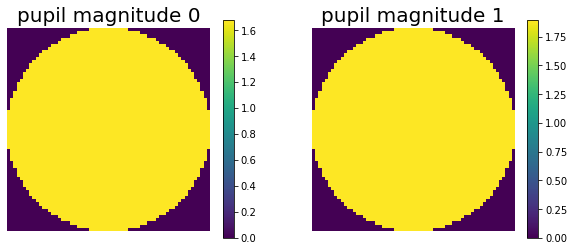

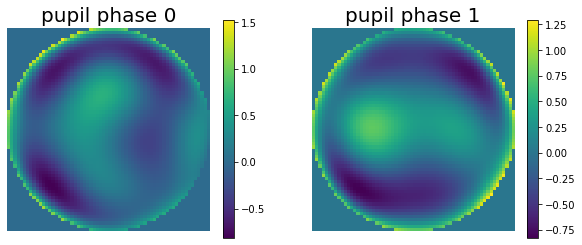

In [68]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

[[ 1.0096 -0.0188  0.    ]
 [ 0.0423  0.8256  0.    ]
 [17.814  -6.4621  1.    ]]


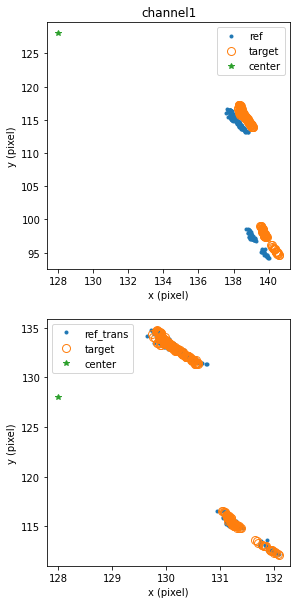

In [69]:
showtransform(f)
np.set_printoptions(precision=4,suppress=True)
print(f.res.T)

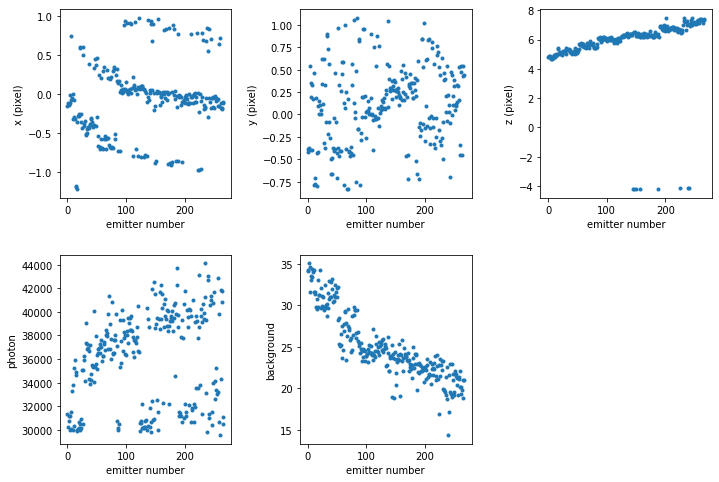

In [70]:
showlearnedparam_insitu(f,p)

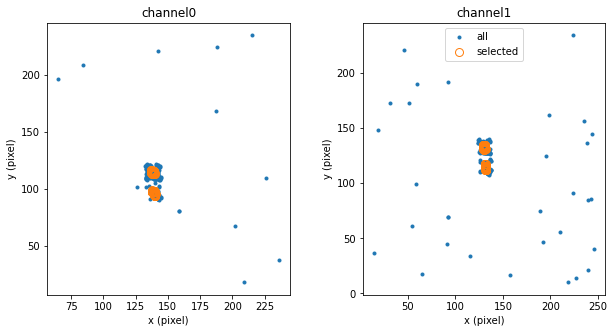

In [71]:
showcoord(f,p)

#### Ouput parameters

In [11]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['I_model', 'I_model_bead', 'I_model_reverse', 'apodization', 'bg', 'cor', 'cor_all', 'drift_rate', 'intensity', 'offset', 'pos', 'pupil', 'sigma', 'zernike_coeff', 'zernike_polynomial']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
